In [10]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.feature_selection import SelectPercentile, mutual_info_classif
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


In [11]:
DATA_PATH = 'churn.csv'
df_raw = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head())


Loaded: churn.csv
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned.columns = [c.strip() for c in cleaned.columns]
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    return cleaned


def split_features_target(df: pd.DataFrame, target_col: str = 'Exited'):
    working = df.copy()
    id_like_cols = [c for c in ['RowNumber', 'CustomerId', 'Surname'] if c in working.columns]
    working = working.drop(columns=id_like_cols, errors='ignore')

    if target_col not in working.columns:
        raise ValueError(f"Target column '{target_col}' not found.")

    X = working.drop(columns=[target_col])
    y = working[target_col].astype(int)
    return X, y


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=['number']).columns.tolist()
    categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    try:
        onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('cat', categorical_pipeline, categorical_features),
        ],
        remainder='drop'
    )


In [13]:
df = basic_cleaning(df_raw)
X, y = split_features_target(df, target_col='Exited')
preprocessor = build_preprocessor(X)

print('Cleaned shape:', df.shape)
print('Class distribution (Exited):')
print(y.value_counts(normalize=True).rename('ratio'))

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(10))


Cleaned shape: (10000, 14)
Class distribution (Exited):
Exited
0    0.7963
1    0.2037
Name: ratio, dtype: float64


Series([], dtype: int64)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


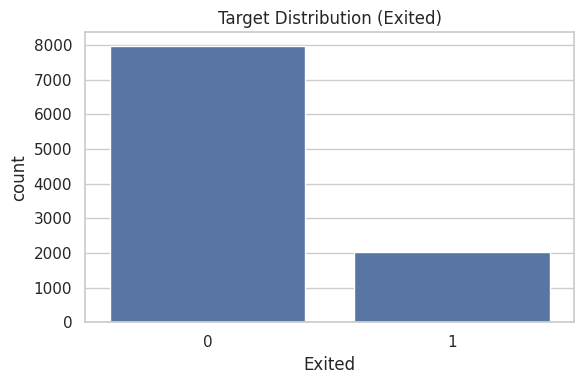

In [14]:
display(df.describe(include='all').T)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited')
plt.title('Target Distribution (Exited)')
plt.tight_layout()
plt.show()


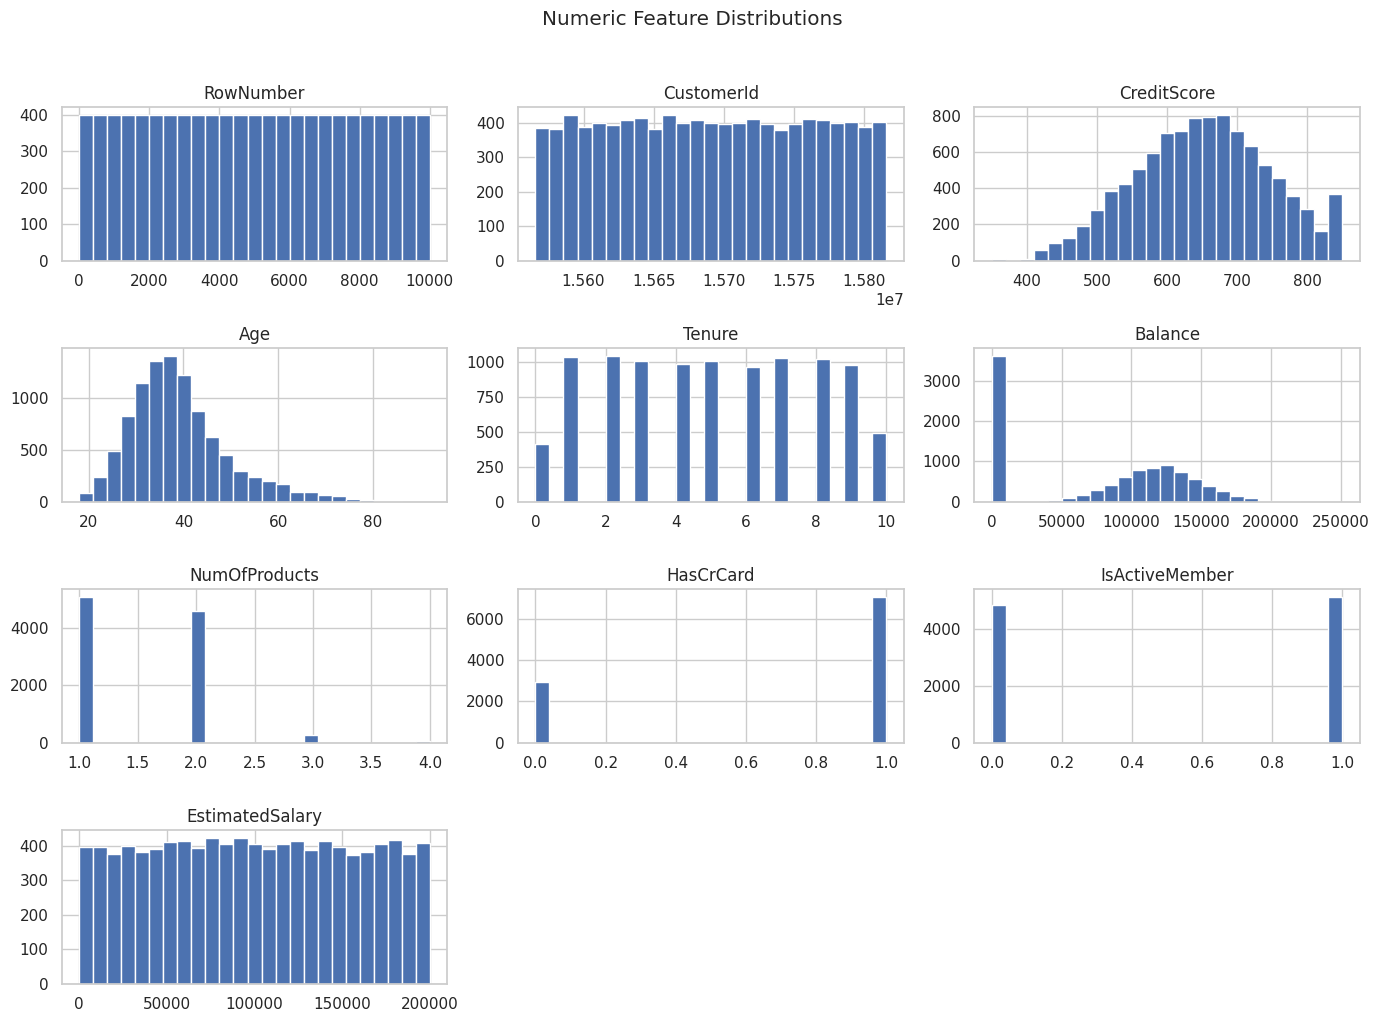

In [15]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_no_target = [c for c in numeric_cols if c != 'Exited']

df[numeric_no_target].hist(figsize=(14, 10), bins=25)
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()


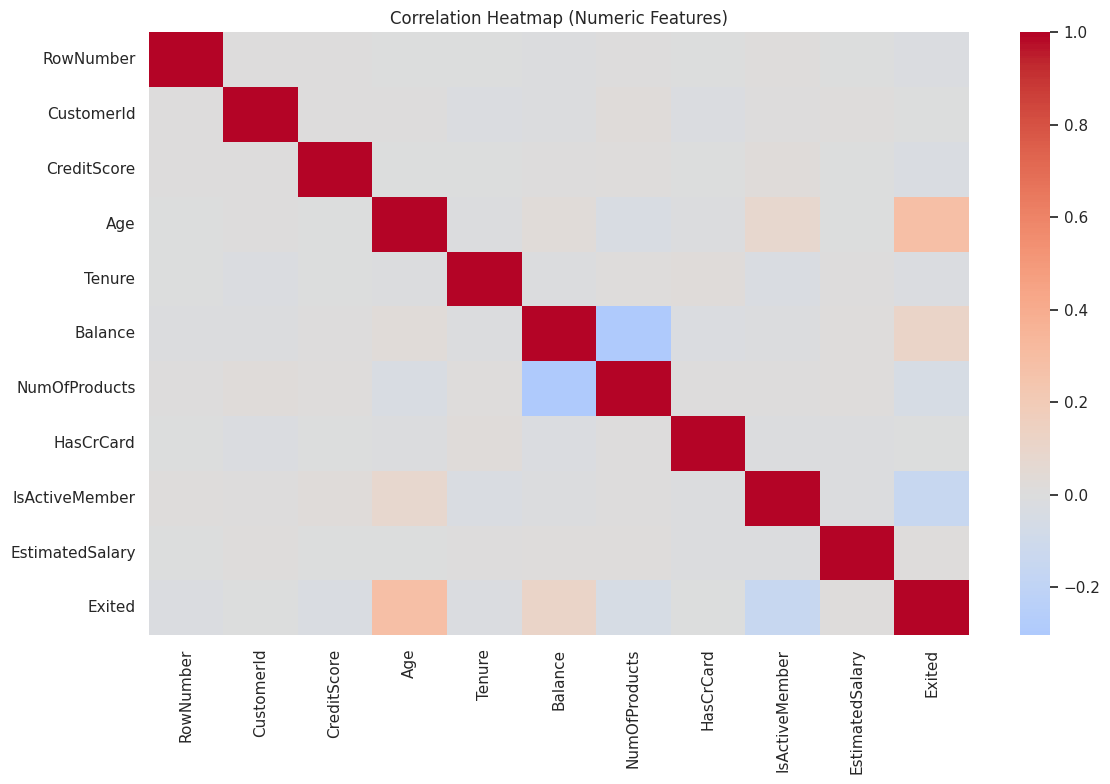

In [16]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


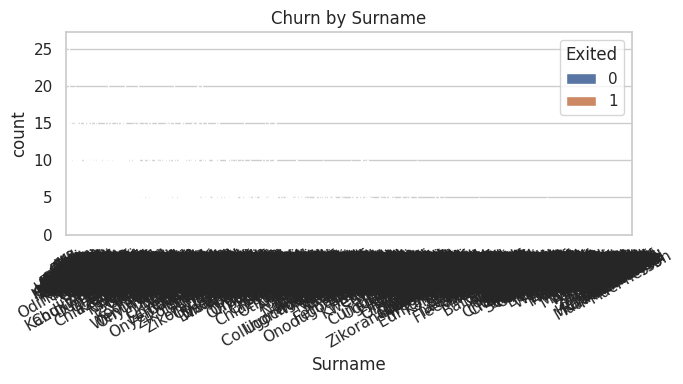

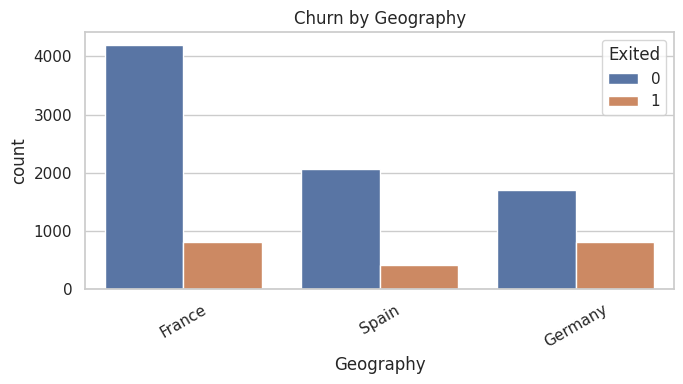

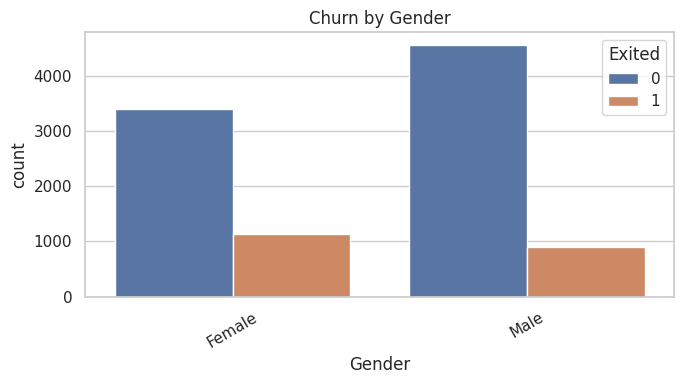

In [17]:
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue='Exited')
    plt.title(f'Churn by {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('normalizer', Normalizer(norm='l2')),
    ('feature_selection', SelectPercentile(score_func=mutual_info_classif, percentile=100)),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

param_grid = {
    'feature_selection__percentile': [70, 85, 100],
    'svm__kernel': ['rbf', 'linear', 'poly'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto'],
    'svm__degree': [2, 3],
    'svm__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print('Best CV F1:', round(grid_search.best_score_, 4))
print('Best Params:', grid_search.best_params_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best CV F1: 0.5955
Best Params: {'feature_selection__percentile': 70, 'svm__C': 1, 'svm__class_weight': 'balanced', 'svm__degree': 3, 'svm__gamma': 'scale', 'svm__kernel': 'poly'}


In [19]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

print('Test Metrics:')
for name, value in metrics.items():
    print(f'{name}: {value:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Test Metrics:
Accuracy: 0.7920
Precision: 0.4928
Recall: 0.7543
F1-score: 0.5961
ROC-AUC: 0.8562

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.49      0.75      0.60       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000



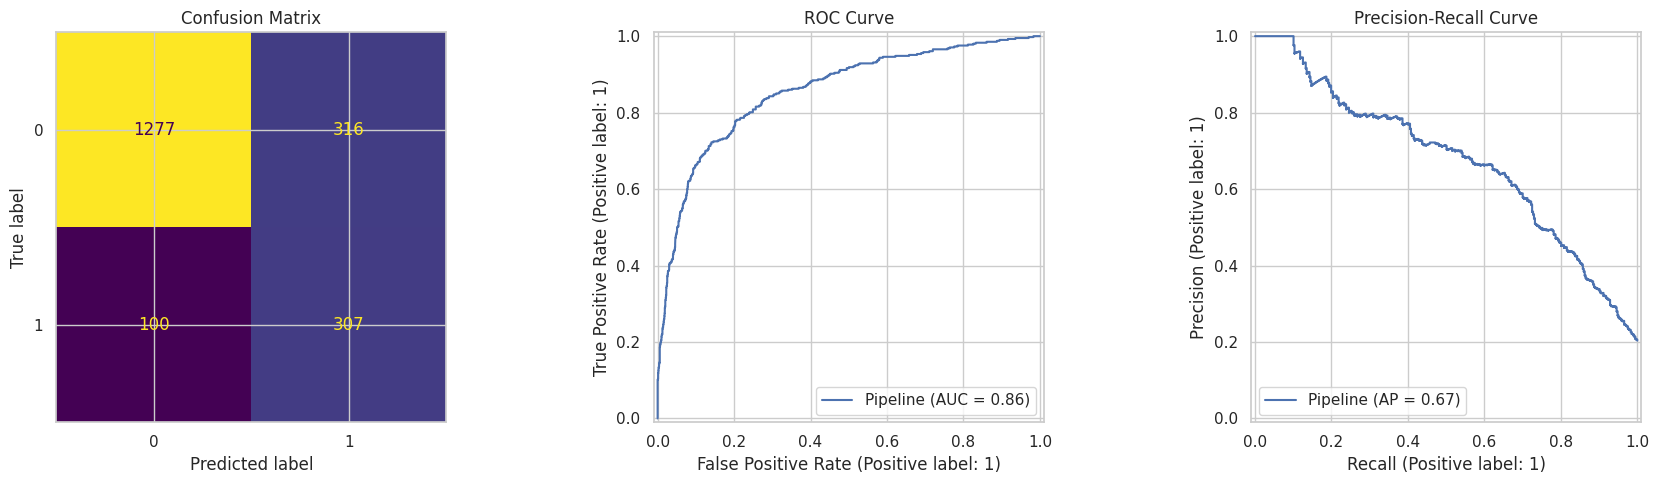

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


In [21]:
artifact_dir = Path('artifacts')
artifact_dir.mkdir(parents=True, exist_ok=True)

artifact_path = artifact_dir / 'svm_churn_model.pkl'
artifact = {
    'model': best_model,
    'input_features': X.columns.tolist(),
    'target': 'Exited',
    'best_params': grid_search.best_params_
}

joblib.dump(artifact, artifact_path)
print('Saved model artifact to:', artifact_path.resolve())


Saved model artifact to: /home/adithyan/PycharmProjects/SVM-Project/artifacts/svm_churn_model.pkl
